In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

In [3]:
df=pd.read_csv("knn_telecom.csv")

In [5]:
df=df.loc[:,~df.columns.str.lower().str.lower().str.contains("id")]


In [7]:
for col in df.columns:
    if df[col].dtype=="object":
        df[col]=df[col].fillna(df[col].mode()[0])
    else:
        df[col]=df[col].fillna(df[col].median())

In [9]:
X=df.drop("Churn",axis =1)
y= df["Churn"]
numeric_features =X.select_dtypes(include=["int64","Float64"]).columns
categorical_features= X.select_dtypes(include=["object"]).columns

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric_features),
        ("cat",OneHotEncoder(drop="first"),categorical_features)
    ]
)

In [15]:
skf =StratifiedKFold(n_splits=5 ,shuffle=True, random_state=42)

k_values = range(1,16)
cv_scores = []

for k in k_values:
    model = Pipeline([
        ("preprocessing" , preprocessor),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(model,X,y, cv=skf, scoring="accuracy")
    cv_scores.append(scores.mean())

for k,score in zip(k_values,cv_scores):
    print(f"K={k} | CV Accuracy = {round(score,4)}")

best_k=k_values[np.argmax(cv_scores)]
print("\nBest K Selected: ",best_k)

K=1 | CV Accuracy = 0.9533
K=2 | CV Accuracy = 0.94
K=3 | CV Accuracy = 0.9667
K=4 | CV Accuracy = 0.96
K=5 | CV Accuracy = 0.96
K=6 | CV Accuracy = 0.96
K=7 | CV Accuracy = 0.96
K=8 | CV Accuracy = 0.9667
K=9 | CV Accuracy = 0.96
K=10 | CV Accuracy = 0.96
K=11 | CV Accuracy = 0.96
K=12 | CV Accuracy = 0.96
K=13 | CV Accuracy = 0.9667
K=14 | CV Accuracy = 0.9667
K=15 | CV Accuracy = 0.96

Best K Selected:  3


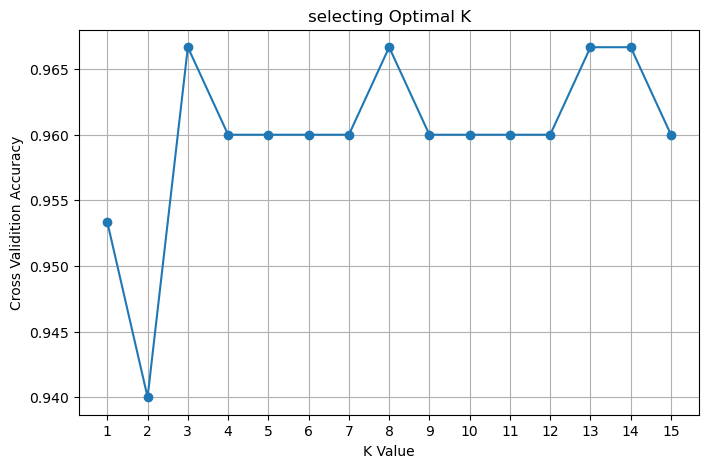

In [19]:
plt.figure(figsize= (8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Cross Validition Accuracy")
plt.title("selecting Optimal K")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
final_model=Pieline([
    ("pr